In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Some code (not all) for a group final project I did for STAT498J - Probability Models in Fall 2023. The original code was written in ```R```. The goal of this project was to develop a Markov Chain for modeling math grades of UMD students for a particular sequence of math courses. The standard sequence would go something like:

```calc1 -> calc2 -> calc3 -> linear algebra or differential equations```

The data was collected via an anonymous form asking UMD students to enter the course they took (Calculus 1 through Differential Equations) and the grade they got in the course. Transition probabilities were then estimated from the number of students sampled and a Markov Chain can be simulated from there

In [3]:
grades_data = pd.read_csv(r'C:\Users\jluo1\Documents\repos\bayesian_statistics\data\stat498j_data.csv')

In [4]:
grades_data["calc1"] = grades_data["calc1"].apply(lambda x: "Other/AP" if "Taken" in x else x)
grades_data["calc2"] = grades_data["calc2"].apply(lambda x: "Other/AP" if "Taken" in x else x)
grades_data["calc3"] = grades_data["calc3"].apply(lambda x: "Other/AP" if "Taken" in x else x)
grades_data["diffeq"] = grades_data["diffeq"].apply(lambda x: "Other/AP" if "Taken" in x else x)
grades_data["linalg"] = grades_data["linalg"].apply(lambda x: "Other/AP" if "Taken" in x else x)
grades_data["student_num"] = range(1,len(grades_data) + 1)

In [5]:
grades_data.head(5)

,Timestamp,calc1,calc2,calc3,linalg,diffeq,student_num
0,11/29/2023 15:20:03,Other/AP,Other/AP,A,A,A,1
1,11/29/2023 15:20:31,Other/AP,Not taken,Not taken,B,Not taken,2
2,11/29/2023 15:22:11,Other/AP,Other/AP,A,B,B,3
3,11/29/2023 15:22:55,Not taken,Not taken,A,B,B,4
4,11/29/2023 15:28:07,A,A,A,B,Not taken,5


In [6]:
calc1_2 = pd.crosstab(grades_data["calc1"], grades_data["calc2"])
calc2_3 = pd.crosstab(grades_data["calc2"], grades_data["calc3"])
calc2_la = pd.crosstab(grades_data["calc2"], grades_data["linalg"])
calc2_3 = pd.crosstab(grades_data["calc2"], grades_data["calc3"])
calc3_de = pd.crosstab(grades_data["calc3"], grades_data["diffeq"])
la_de = pd.crosstab(grades_data["linalg"], grades_data["diffeq"])

## Creating a one-step transition matrix

### Transition matrix from calculus 1 to calculus 2


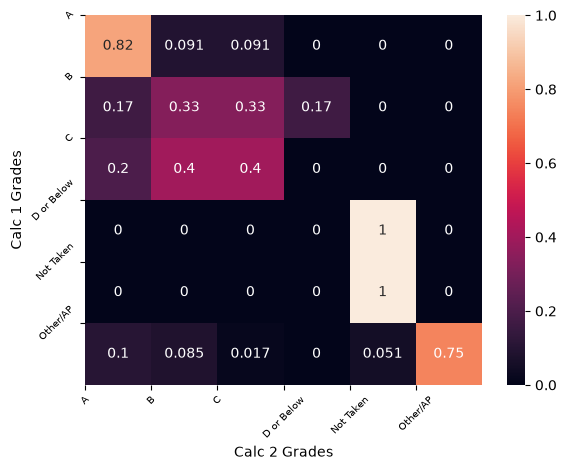

In [7]:
def one_step_matrix(contingency_table):
    if type(contingency_table) != np.ndarray:
        contingency_table = np.array(contingency_table)

    prop_table = contingency_table / np.sum(contingency_table, 1, keepdims=True)
    return prop_table

# Transition probabilities from calc1 to calc2
calc1_2_trans = one_step_matrix(calc1_2)

sns.heatmap(data = calc1_2_trans, annot = True)
plt.xticks(ticks = np.arange(0, len(calc1_2_trans)), labels = ["A", "B", "C", "D or Below", "Not Taken", "Other/AP"], size = 7, rotation = 45)
plt.yticks(ticks = np.arange(0, len(calc1_2_trans)), labels = ["A", "B", "C", "D or Below", "Not Taken", "Other/AP"], size = 7, rotation = 45)
plt.xlabel("Calc 2 Grades")
plt.ylabel("Calc 1 Grades")
plt.show()

In [8]:
num_possible_transitions = 4 
num_grade_categories = 6

calc1_transitions = np.zeros((num_grade_categories, num_grade_categories * num_possible_transitions))

for i in range(6):
    calc1_transitions[i, 6:12] = calc1_2_trans[i]

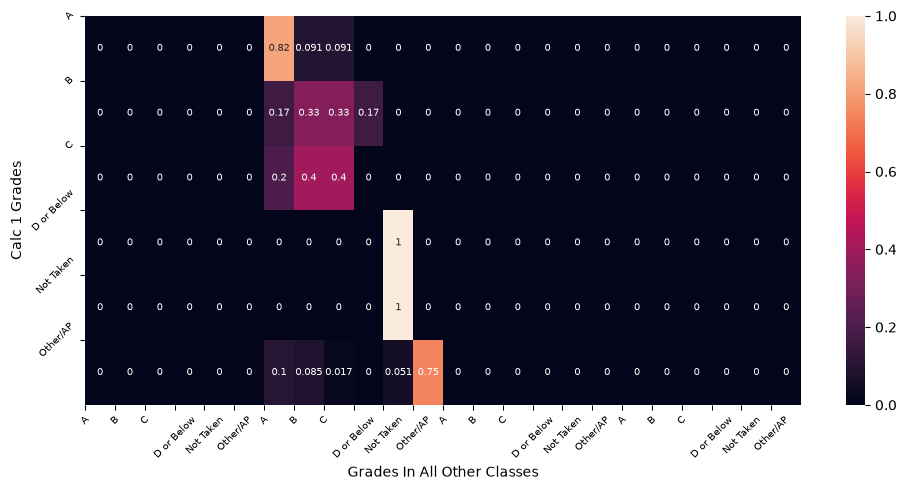

In [9]:
# Full transition matrix (across all course combinations)
_, axs = plt.subplots(figsize = (10,5))

sns.heatmap(data = calc1_transitions, annot = True, annot_kws={"size": 7})
plt.xticks(ticks = np.arange(0, np.shape(calc1_transitions)[1]), 
           labels = np.tile(["A", "B", "C", "D or Below", "Not Taken", "Other/AP"],4), size = 7, rotation = 45)
plt.yticks(ticks = np.arange(0, np.shape(calc1_2_trans)[1]), 
           labels = np.tile(["A", "B", "C", "D or Below", "Not Taken", "Other/AP"],1), size = 7, rotation = 45)

plt.xlabel("Grades In All Other Classes")
plt.ylabel("Calc 1 Grades")
plt.tight_layout()
plt.show()

### Transition matrix from calculus 2 to calculus 3

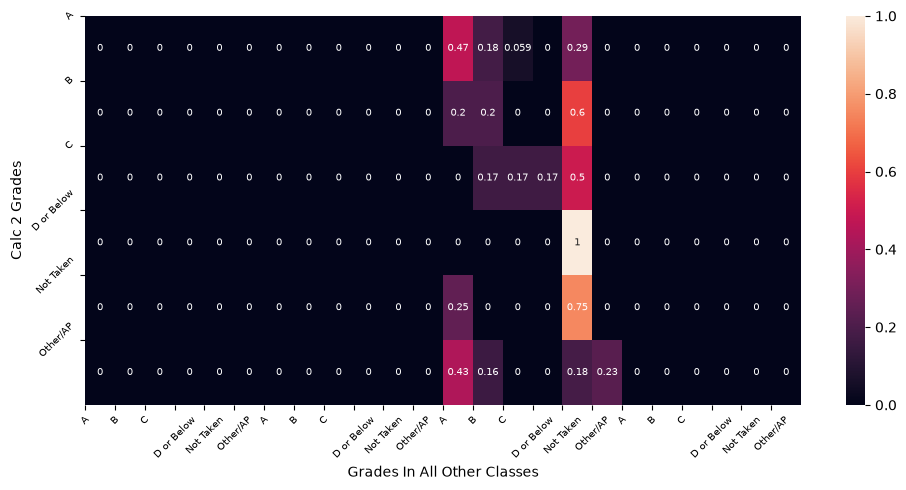

In [10]:
calc2_3_trans = one_step_matrix(calc2_3)

calc2_transitions = np.zeros((num_grade_categories, num_grade_categories * num_possible_transitions))

for i in range(6):
    calc2_transitions[i, 12:18] = calc2_3_trans[i]

_, axs = plt.subplots(figsize = (10,5))

sns.heatmap(data = calc2_transitions, annot = True, annot_kws={"size": 7})
plt.xticks(ticks = np.arange(0, np.shape(calc2_transitions)[1]), 
           labels = np.tile(["A", "B", "C", "D or Below", "Not Taken", "Other/AP"],4), size = 7, rotation = 45)
plt.yticks(ticks = np.arange(0, np.shape(calc2_3_trans)[1]), 
           labels = np.tile(["A", "B", "C", "D or Below", "Not Taken", "Other/AP"],1), size = 7, rotation = 45)

plt.xlabel("Grades In All Other Classes")
plt.ylabel("Calc 2 Grades")
plt.tight_layout()
plt.show()

### Transition matrix from calculus 3 to differential equations

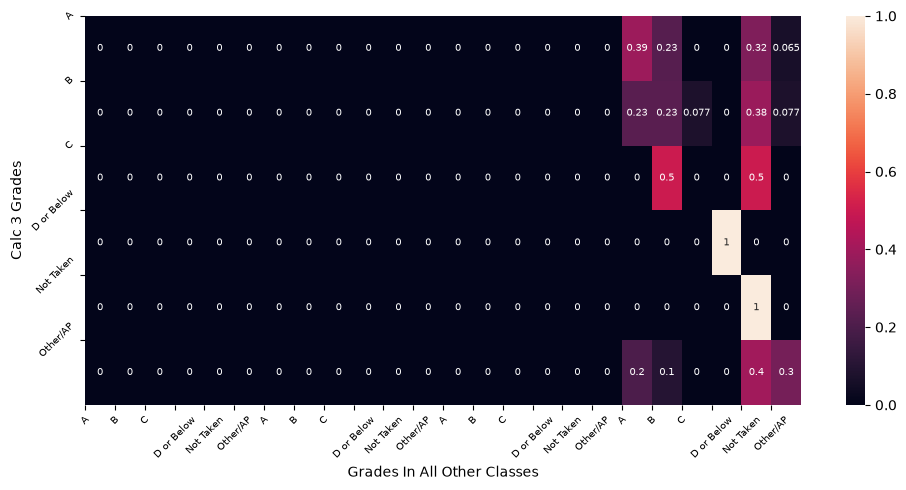

In [11]:
calc3_de_trans = one_step_matrix(calc3_de)

calc3_transitions = np.zeros((num_grade_categories, num_grade_categories * num_possible_transitions))

for i in range(6):
    calc3_transitions[i, 18:24] = calc3_de_trans[i]

_, axs = plt.subplots(figsize = (10,5))

sns.heatmap(data = calc3_transitions, annot = True, annot_kws={"size": 7})
plt.xticks(ticks = np.arange(0, np.shape(calc3_transitions)[1]), 
           labels = np.tile(["A", "B", "C", "D or Below", "Not Taken", "Other/AP"],4), size = 7, rotation = 45)
plt.yticks(ticks = np.arange(0, np.shape(calc3_de_trans)[1]), 
           labels = np.tile(["A", "B", "C", "D or Below", "Not Taken", "Other/AP"],1), size = 7, rotation = 45)

plt.xlabel("Grades In All Other Classes")
plt.ylabel("Calc 3 Grades")
plt.tight_layout()
plt.show()

### Transition from differential equations (trivial case)

In [12]:
de_transitions = np.zeros((num_grade_categories, num_grade_categories * num_possible_transitions))
de_transitions[:, 18:24] = np.eye(6)

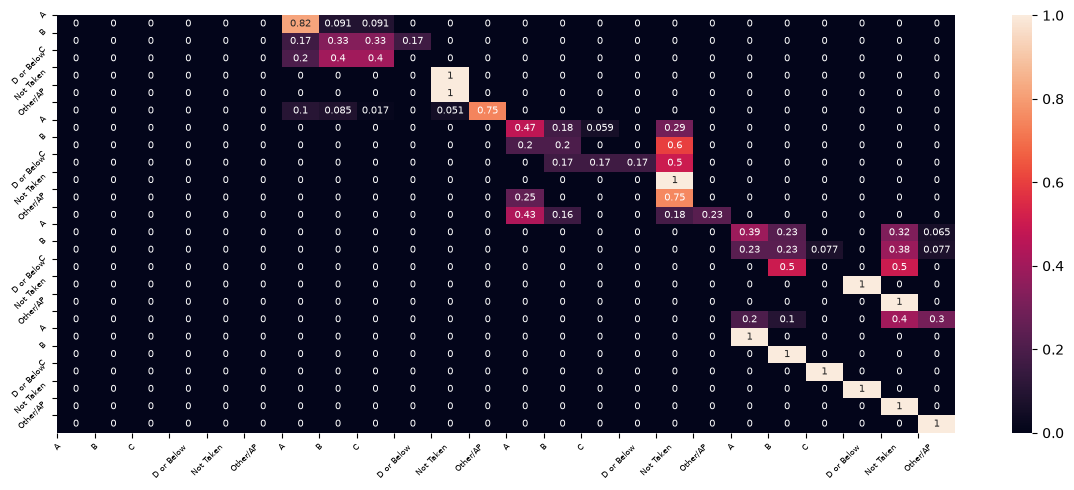

In [13]:
full_transition_matrix = np.vstack([calc1_transitions, calc2_transitions, calc3_transitions, de_transitions])

def plot_full_transition_matrix(mat: np.ndarray):
    _, __ = plt.subplots(figsize = (12,5))
    sns.heatmap(data = mat, annot = True, annot_kws={"size": 7})
    plt.xticks(ticks = np.arange(0, np.shape(mat)[1]), 
            labels = np.tile(["A", "B", "C", "D or Below", "Not Taken", "Other/AP"],4), size = 6, rotation = 45)
    plt.yticks(ticks = np.arange(0, np.shape(mat)[1]), 
            labels = np.tile(["A", "B", "C", "D or Below", "Not Taken", "Other/AP"],4), size = 6, rotation = 45)

    plt.tight_layout()
    plt.show()

plot_full_transition_matrix(full_transition_matrix)

Matrix to the 2 power 



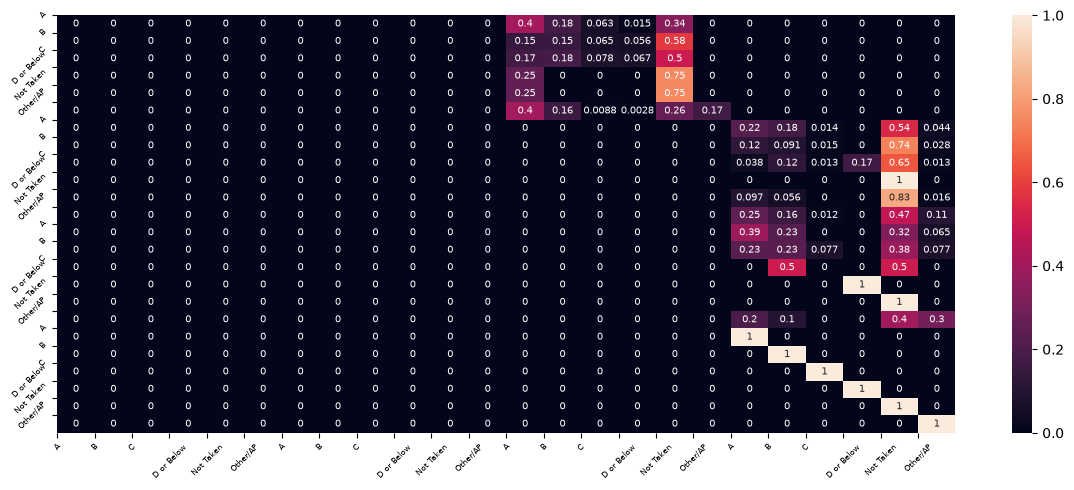

Matrix to the 2 power 

Matrix to the 3 power 



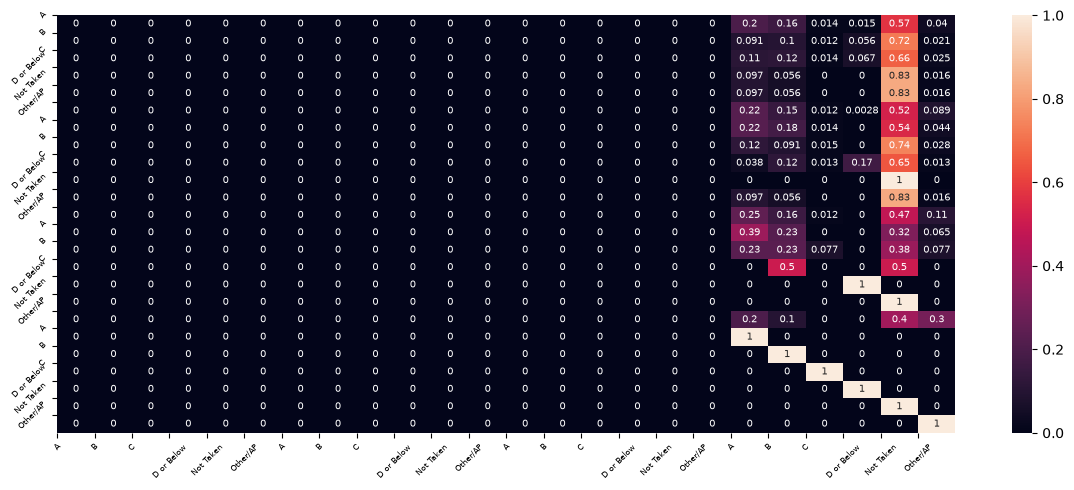

In [14]:
def matrix_power(transition_matrix: np.ndarray, n: int):
    mat1 = transition_matrix
    if n == 1:
        return mat1
    else:
        for i in range(2,n+1):
            transition_matrix = np.matmul(mat1, transition_matrix)
            print(f"Matrix to the {i} power \n")

        return transition_matrix


full_transition_matrix_2 = matrix_power(full_transition_matrix, 2)
plot_full_transition_matrix(full_transition_matrix_2)

full_transition_matrix_3 = matrix_power(full_transition_matrix, 3)
plot_full_transition_matrix(full_transition_matrix_3)